# Summer 2026 Personal Project (WIP)  
By Evan O'Malley

---

**Context**  

---
        The inspiration for this project arose while reflecting on my progress as a university student. As an incoming third-year, I am well-equipped with the tools and methods of elementary data-science. However, I feel I am not backed by the relevant works.  
        To amend this, I set out to complete a data-science personal project this summer 2026 and finally staple something to my portfolio. I also figure it's worthwhile to assess and sharpen my data-science abilities as my upcoming courses will undoubtedly require my best.  
        Most importantly, I want to map the intricacies of my personal data-science techniques: my favors, my organization, my habits, and the like.  
        This project surrounds Pew Research's [Western Europe Survey Dataset](https://www.pewresearch.org/dataset/western-europe-survey-dataset/). I chose it for little more than personal intereset. What greater rationale is there for a personal project, after all.  

---

**Project Goals**  

---
        It would be quite the waste if I complete this project and learn nothing from it, so below are all that I wish to exercise.  

- **Effective Use of Library Functions**

        It should be no surprise I will use a few of the essential data-science python packages. This past year, I've learnt the differences between interpreted and compiled languages, and gained insights on the importance of these packages. Hence, I will attempt to use them to their fullest here.  
        In particular, I will steer clear of instruction-intense programming in native python, avoiding `for` loops, `while` loops, homemade functions, and repetitive code unless I find no alternative. Referencing documentation for more efficient methods will be a frequent practice.

- **Producing Legible Work, as if for Presentation**  

        I will be supplementing resumes and online profiles with this project – I would guess you may have encountered it this way – so I will focus on keeping my work tidy, as both a curtesy to the reader and a service to myself.  
        Readability to me mostly takes place as concise commenting, intuitive naming schemes, DRY principles, and ample whitespace. Another unignorable factor due to the nature of the python notebook is the structure. The notebook should flow and build upon itself, following the insticts of inspiration, aided by Markdown. It should not suggest skipping sections, visiting future sections, addressing multiple sections simultaneously, or whatever else may impair the reader's experience.  

- **Building a Coherent Environment**  

        The tools I create for this project should be robust and comprehensive, properties to give me freedoms to manipulate and process the data. It would be as if I am making my own package for this project, and anyone could gain access and continue my work.  
        Besides the legibility conditions above, I want all objects (classes, functions, instances, etcetera) to be accessible and adaptable to whatever I may imagine. This entails a healthy serving of docstrings, error handling, data storage, case-awareness, abstraction, and file management.  

- **Git**

        I lack much Git experience at the moment, and given the intended publicity of this and future projects, I have to acclimate myself to it.  
        This also gives the opportunity to develop healthy Git habits surrounding frequent editions and intellegent messaging.  

---

Also, no AI, as I have a head on my shoulders I like to use instead.

---

## Initialization

### Notebook Setup  
Imports files and packages

In [1]:
# Necessary Imports
# Pretty Lean
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from warnings import simplefilter
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

rel_path = "Data/Western_Europe_Public_Data_Church_Tax_Added.csv"
codebook_rel_path = "Codebooks/codebook.txt"

### Precursor Structures
Paragraph

In [2]:
class OrderLegend:
    def __init__(self, order: str, legend: dict):
        self.order = order
        self.legend = legend
        
    def ord(self):
        return self.order
    
    def leg(self):
        return self.legend
    
    def values(self):
        return self.legend.values()

    def keys(self):
        return self.legend.keys()

    def items(self):
        return self.legend.items()

    def len(self):
        return len(self.legend)

    def __repr__(self):
        return f"{self.order}, {self.legend}"

    def __str__(self):
        return f"{self.order}, {self.legend}"

    def __getitem__(self, i):
        return self.legend[i]

### File Parsing
Makes codebook.txt into usable object

In [3]:
with open(codebook_rel_path) as f:
    codebook = f.read()

def parse_next(terminator):
    assert len(terminator) == 1, "Terminator must be one character"
    global s
    global codebook
    
    passage = ""
    while codebook[s] != terminator:
        passage += codebook[s]
        s += 1
    s += 1
        
    return passage


s = 0
Legends = {}

while s < len(codebook):
    col_legend = {}
    name = parse_next(':')
    order = parse_next('{')
    s += 1
    
    if "[COUNTRY]" in name:
        while codebook[s] != '!':
            idx = int(parse_next(' '))
            val = parse_next('\n')
            col_legend[idx] = val
        s += 1

        # I thought I needed this line at one point,
        # but I have not used it
        # Legends[name.replace("[COUNTRY]", "")] = OrderLegend(order, {})
        
        while codebook[s] != '}':
            CTY = codebook[s:s+3]
            s += 5
            
            while codebook[s] != '}':
                idx = int(parse_next(' '))
                val = parse_next('\n')
                col_legend[idx] = val
            s += 2

            col_legend[98] = "Don't know"
            col_legend[99] = "Refused"

            Legends[
                name.replace("[COUNTRY]", CTY)
            ] = OrderLegend(order, col_legend)
            
        s += 2
            
    else:
        while codebook[s] != '}':
            idx = int(parse_next(' '))
            val = parse_next('\n')
            col_legend[idx] = val
        s += 2

        col_legend[98] = "Don't know"
        col_legend[99] = "Refused"

        Legends[name] = OrderLegend(order, col_legend)

### Parent Restitching
These cells altar the parent DataFrame and cannot be rerun

In [4]:
Parent_DF = pd.read_csv(rel_path, skipinitialspace=True)

In [5]:
# Move QRID column to index
Parent_DF.set_index("QRID", inplace = True)

In [6]:
# Fix respose layout for Q9
q9_cols = Parent_DF.apply(lambda x: x.name[1] == "9")
q9_cols = Parent_DF.loc[:, q9_cols]
q9 = q9_cols.apply(lambda x: sum(x * (2 ** np.arange(1, len(x) + 1))),
                   axis = 1
     )

Parent_DF.insert(16, "Q9", q9)
Parent_DF.drop(q9_cols, axis = 1, inplace = True)

In [7]:
# Removing QS1... variables
# becuase they stand for regions and are indecipherable or redacted
# Similaryly removing qbornmoverec variable
QS1_cols = [i for i in Parent_DF.columns if i.lower()[:3] == "qs1"]

Parent_DF.drop(QS1_cols, axis = 1, inplace = True)
Parent_DF.drop("qbornmoverec", axis = 1, inplace = True)

In [8]:
# Knit QIDEOLOGY, QIDEOLOGYa, and QIDEOLOGYb,
# as they are nearly identical
ideology_rec = Parent_DF["QIDEOLOGY"].map(
                   lambda x: x + 1 if x < 90 else x
               )
ideologya_rec = Parent_DF["QIDEOLOGYa"].map(
                    lambda x: x + 1 if x< 90 else x
                )

Parent_DF["QIDEOLOGY"] = Parent_DF["QIDEOLOGYb"
                             ].fillna(ideology_rec).fillna(ideologya_rec)

Parent_DF.drop(["QIDEOLOGYa", "QIDEOLOGYb"], axis = 1, inplace = True)

In [9]:
# Knit QDENOM[COUNTRY] columns
# as they use identical enumerations
qdenom = pd.Series([]).reindex(Parent_DF.index)
qdenom_cols = Parent_DF.loc[:,
                  Parent_DF.apply(lambda x: x.name[:6].lower() == "qdenom")
              ]

qdenom_cols.apply(lambda x: qdenom.fillna(x, inplace = True))
Parent_DF.insert(26, "QDenom", qdenom)

Parent_DF.drop(qdenom_cols, axis = 1, inplace = True)

In [10]:
# Same goes for QCHDENOM[Country] columns
qchdenom = pd.Series([]).reindex(Parent_DF.index)
qchdenom_cols = Parent_DF.loc[:, 
                    Parent_DF.apply(lambda x: x.name[:8].lower() == "qchdenom")
                ]

qchdenom_cols.apply(lambda x: qchdenom.fillna(x, inplace = True))
Parent_DF.insert(27, "QChdenom", qchdenom)

Parent_DF.drop(qchdenom_cols, axis = 1, inplace = True)

In [11]:
# Same goes for QCURRELrec and QCURRELDrec columns
qcurrel = Parent_DF["QCURRELrec"].replace([91, 98, 99], np.nan)
Parent_DF["QCURRELrec"] = qcurrel.fillna(Parent_DF["QCURRELDrec"])

Parent_DF.drop("QCURRELDrec", axis = 1, inplace = True)

In [12]:
# Repair column naming scheme
def title_scheme(title: str):
    # Cumulatively adjusts column titles according to scheme described below
    new_title = title

    # Remove instances of "rec", signifying recoded variables

    if new_title[-3:].lower() == "rec":
        new_title = new_title[:-3]

    # Normalize Capitalization Scheme
    # "country" -> "Country"
    # "QCURREL", "qcurrel" -> "QCurrel"
    
    if new_title[0].lower() != 'q':
        new_title = new_title.title()
        
    else:
        new_title = 'Q' + new_title[1:].title()
    
    # Capitalize suffixes signifying country
    # "QDenomaut" -> "QDenomAUT"
    
    if new_title[-3:].upper() in Legends["Country"].values():
        new_title = new_title[:-3] + new_title[-3:].upper()

    if new_title[-4:-1].upper() in Legends["Country"].values():
        new_title = new_title[:-4] + new_title[-4:-1].upper() + new_title[-1]

    # Some questions are divided into cases a, b, c, etcetera
    # Denotation will be separated from the main title and uncapitalized
    # "Q4A", "Q4B" -> "Q4_a", Q4_b"
    # These are dicipherable by last 2 characters of the title

    NumCap = new_title[-2].isnumeric() and new_title[-1].isupper()
    CapUncap = new_title[-2].isupper() and new_title[-1].islower() 

    if NumCap or CapUncap:
        new_title = new_title[:-1] + "_" + new_title[-1].lower()

    # Choice adjustments
    if new_title[:4] == "QPty":
        if new_title[4] == 'a':
            new_title = new_title[:4] + "potvot" + new_title[5:]
        elif new_title[4] == 'b':
            new_title = new_title[:4] + "fvr" + new_title[5:]
        else:
            new_title = new_title[:4] + "cls" + new_title[4:]

    rename_key = {"QCitizen1" : "QCitizen",
                  "QBornc" : "QBornmthr",
                  "QBorne" : "QBornfthr",
                  "QChilda" : "QChild",
                  "QHhch" : "QParent"}

    if new_title in rename_key.keys():
        new_title = rename_key[new_title]
    
    return new_title

Parent_DF.rename(title_scheme, axis = 1, inplace = True)

In [13]:
# Make Legends Comprehensive
for l in Parent_DF.columns:
    if l in Legends:
        continue
    else:
        Legends[l] = OrderLegend(Legends[l[:-1]].ord(), Legends[l[:-1]].leg())

In [14]:
# Contrain Values
# This will ruin all cardinal columns and Q9
Parent_DF_tmp = Parent_DF.copy()
Parent_DF = Parent_DF.apply(
                lambda x: x.where(np.isin(
                    x, np.array(list(Legends[x.name].keys()))
            )))

# This will fix them
Parent_DF["Q9"] = Parent_DF_tmp["Q9"]
for i in Legends.keys():
    if Legends[i].ord() == "Cardinal":
        Parent_DF[i] = Parent_DF_tmp[i]

### Further Preparations
Functions for table manipulations

In [15]:
# Create Generalized list of Qs in order
# This will not be useful later
# strip_countries was though
def strip_countries(title: str):
    # Code primary lifted from title_scheme function
    if title[-3:] in Legends["Country"].values():
        return title[:-3]

    if title[-5:-2] in Legends["Country"].values():
        return title[:-5] + title[-2:]

    return title

survey_order = Parent_DF.apply(
                   lambda x: strip_countries(x.name)
               ).drop_duplicates().to_numpy()

In [16]:
# Function to disambiguate and ambiguate enumerations
def disambiguate(col: pd.Series):
    if col.dtypes != str:
        return col.dropna().map(lambda x: Legends[col.name][x])
    else:
        return col

def ambiguate(col: pd.Series):
    if col.dtypes in [int, float]:
        return col
    else:
        reverse_legend = {y:x for x,y in Legends[col.name].items()}
        return col.dropna().map(lambda x: reverse_legend[x])

In [17]:
def Hist(data = np.array([]),
         title = None,
         xlab = None,
         ylab = "Count",
         bins = 10,
         xmin = None, xmax = None,
         ymin = None, ymax = None
        ):
    # Default hist function

    fig, ax = plt.subplots()

    if title: ax.set_title(title, size = 8)
    if xlab: ax.set_xlabel(xlab, size = 6)
    if ylab: ax.set_ylabel(ylab, size = 6)
    if xmin: ax.set_xlim(xmin = xmin)
    if xmax: ax.set_xlim(xmax = xmax)
    if ymin: ax.set_ylim(ymin = ymin)
    if ymax: ax.set_ylim(ymax = ymax)

    fig.set_dpi(250)
    fig.set_size_inches(3, 2)
    ax.hist(data, bins = bins)
    ax.tick_params(labelsize = 5, size = 2)

    return (fig, ax)

In [18]:
# Function to divide tables into cardinalities
if False:
    def SepOrder(df: pd.DataFrame, cardinality_arg: str):
        return df.loc[:, df.apply(
                   lambda x: cardinality(x.name) == cardinality_arg
               )]

In [19]:
# Function to divide tables into countries
# Returns a dictionary of the division
if False:
    def SepCountry(refdf: pd.DataFrame):
        df = refdf.copy()
        country_dfs = {}
        if "Country" not in df:
            df = df.join(Parent_DF["Country"], how = "left")
        df["Country"] = disambiguate(df["Country"])
    
        for c in df["Country"].dropna().unique():
            country_df = df.copy()
            country_df = country_df.locd[country_df["Country"] == c]
            country_df = country_df.loc[:,
                             country_df.apply(lambda x: any(x.notna()) )
                         ]
    
            country_df = country_df.rename(strip_countries, axis = 1)
            country_dfs[c] = country_df.drop("Country", axis = 1)
            
        return country_dfs

In [20]:
# Function to divide tables into belief systems
# Separates Christianity by denomination,
# due to overwhelmingly Christian responses
# Returns a dictionary of the division
if False:
    def SepReligion(refdf: pd.DataFrame):
        df = refdf.copy()
    
        if "QCurrel" not in df:
            df = df.join(Parent_DF["QCurrel"], how = "left")
        df["QCurrel"] = disambiguate(df["QCurrel"])
        
        religion_dfs = {}
        for r in df["QCurrel"].dropna().unique():
            if r != "Christian":
                religion_df = df.copy()
                religion_df = religion_df.loc[religion_df["QCurrel"] == r]
                religion_df = religion_df.loc[:,
                                  religion_df.apply(lambda x: any(x.notna()) )
                              ]
    
                religion_dfs[r] = religion_df.drop("QCurrel", axis = 1)
        
        if "QDenom" not in df:
            df = df.join(Parent_DF["QDenom"], how = "left")
        df["QDenom"] = disambiguate(df["QDenom"])
        
        for d in df["QDenom"].dropna().unique():
            religion_df = df.copy()
            religion_df = religion_df.loc[religion_df["QDenom"] == d]
            religion_df = religion_df.loc[:,
                              religion_df.apply(lambda x: any(x.notna()) )
                          ]
    
            religion_dfs[d] = religion_df.drop(["QCurrel", "QDenom"], axis = 1)
                
        return religion_dfs

### Initialization Summary
Coagulate essenstial information  
- Legends object  
- OrderLegend class and methods

Prepare Parent DataFrame  
- Column cropping  
- Rename scheme

Create DataFrame editing tools  
I have not used any of these meaningfully yet  
- SepOrder  
- SepNation
- SepReligion
- Hist
- Supplementary functions

In [21]:
# Visual aid

## Exploration

### Statistic Inventions
Start inventing some summary statistics

#### Hist_Areas
Paragraph

In [22]:
def Hist_Areas(dfref = pd.DataFrame):
    df = dfref.copy()
    def _responses(x):
        responses = x.value_counts()
        responses[98] = 0
        responses[99] = 0
        responses.drop([98, 99], inplace = True)
        return responses / sum(responses)
        
    return df.apply(_responses)

In [23]:
def Compare_Hist_Areas(col: pd.Series, ref_idx = 0):
    frame = Legends[col.name].len() - 2

    comp_col = col.groupby(level = 0)
    comp_col = comp_col.apply(lambda x: x.dropna().to_numpy())
    comp_col = comp_col.apply(lambda x: np.pad(x, (0, frame - len(x))))

    ref_arr = col[comp_col.index[ref_idx]].dropna().to_numpy()
    ref_arr = np.pad(ref_arr, (0, frame - len(ref_arr)))
    
    return comp_col.apply(lambda x: sum(np.minimum(x, ref_arr)))

### Hist_Areas Satistic
Paragraph

In [24]:
# Compare response distributions across countries
Ordinal_DF = Parent_DF.loc[:,
                 Parent_DF.apply(
                     lambda x: Legends[x.name].ord() == "Ordinal"
             )]
Ordinal_DF = Ordinal_DF.loc[:, Ordinal_DF.apply(
                 lambda x: x.name == strip_countries(x.name)
             )]

Ordinal_DF["Country"] = disambiguate(Parent_DF["Country"])
GB_Nation = Ordinal_DF.groupby("Country").apply(Hist_Areas)

In [25]:
Hist_Areas_DF = pd.DataFrame()
for r in range(16):
    df_r = GB_Nation.apply(Compare_Hist_Areas, ref_idx = r).iloc[r+1:]
    ref_country = GB_Nation.index.get_level_values(0).drop_duplicates()[r]
    df_r.index = pd.MultiIndex.from_arrays(
                     np.stack((
                         np.array([ref_country] * (15-r)), 
                         df_r.index.to_numpy()
                 )))

    Hist_Areas_DF = pd.concat((Hist_Areas_DF, df_r))

HA_Comparisons = np.ravel(Hist_Areas_DF)
per = 5
unlike_lim = np.percentile(HA_Comparisons, per)
alike_lim = np.percentile(HA_Comparisons, 100 - per)

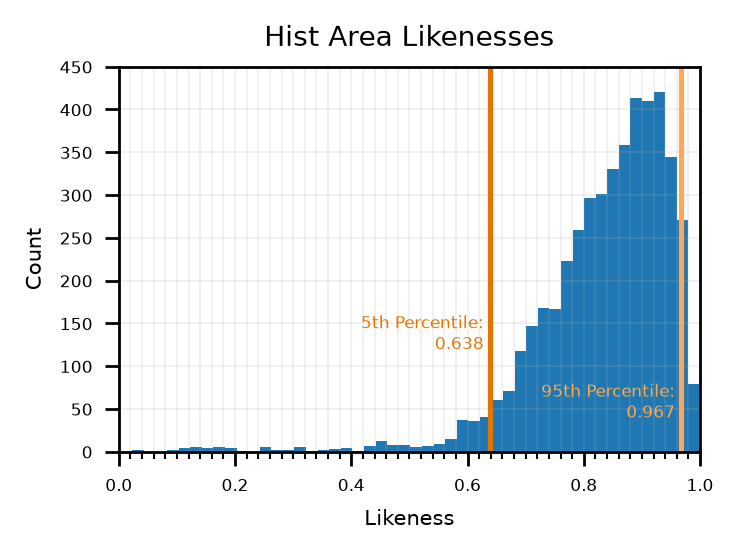

In [26]:
HAfig, HAax = Hist(data = HA_Comparisons,
                   title = "Hist Area Likenesses",
                   xlab = "Likeness",
                   bins = 49,
                   xmin = 0,
                   xmax = 1,
                   ymin = 0,
                   ymax = 450
                  )

HAax.set_xticks(minor = False, ticks = np.arange(0, 6/5, 1/5))
HAax.set_xticks(minor = True, ticks = np.arange(0, 1, 1/50))
HAax.grid(axis = 'x', which = "both", linewidth = 0.1)
HAax.tick_params(which = "minor", labelsize = 5, size = 2)
HAax.tick_params(which = "major", labelsize = 5, size = 4)
HAax.grid(axis = 'y', which = "major", linewidth = 0.1)

HAax.axvline(unlike_lim, color = "xkcd:pumpkin")
HAax.text(unlike_lim - 0.01, 120,
         f"{per}th Percentile:\n{np.round(unlike_lim, 3)}",
         ha = "right", color = "xkcd:pumpkin", size = 5
        )

HAax.axvline(alike_lim, color = "xkcd:pale orange")
HAax.text(alike_lim - 0.01, 40,
         f"{100 - per}th Percentile:\n{np.round(alike_lim, 3)}",
         ha = "right", color = "xkcd:light orange", size = 5
        )

pass # No need to see the MatPlot object

**Attempting to bootstrap**

In [27]:
HA_unlike_lims = np.array([])
HA_means = np.array([])
for h in np.arange(5e3):
    HA_rs = np.random.choice(HA_Comparisons, 
                      size = len(HA_Comparisons), replace = True
                  )
    HA_rs_unlike_lim = np.percentile(HA_rs, per)
    HA_unlike_lims = np.append(HA_unlike_lims, HA_rs_unlike_lim)
    HA_rs_mean = np.mean(HA_rs)
    HA_means = np.append(HA_means, HA_rs_mean)

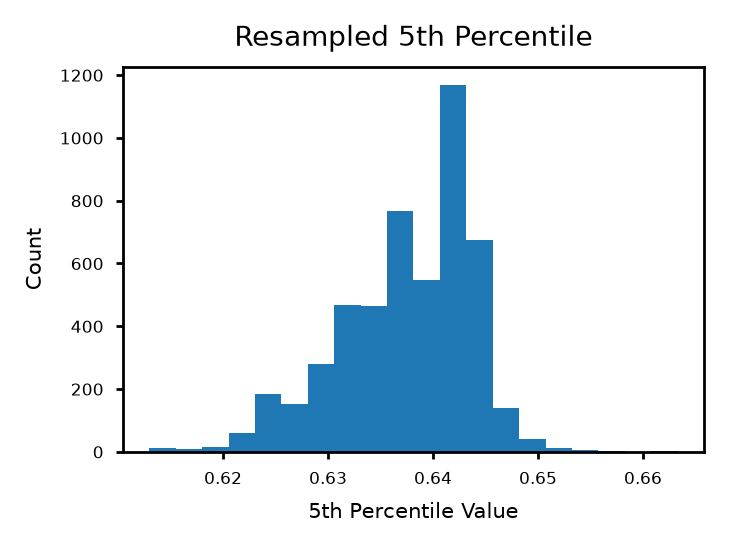

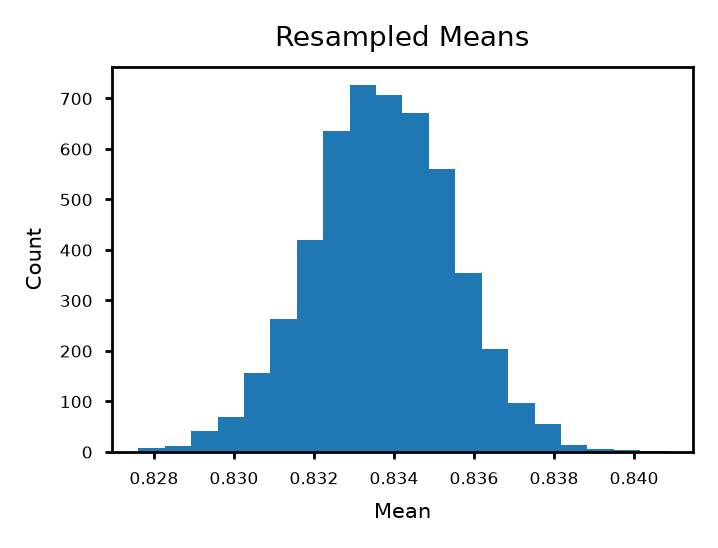

In [28]:
Hist(
    data = HA_unlike_lims,
    title = f"Resampled {per}th Percentile",
    xlab = f"{per}th Percentile Value",
    bins = 20,
)

Hist(
    data = HA_means,
    title = "Resampled Means",
    xlab = "Mean",
    bins = 20
)
pass

__Discovery:__  
Quantiles don't follow the central limit theorem.  
This makes sense, becasue other stats like the maximum don't follow it either.  
I would geuss this is because quantiles, as well as maxima/minima, don't describe the data as a collective, unlike the mean.

In [29]:
Hist_Areas_DF

Q2        Q5        Q6  ...       Q50  QIdeology     Isced
AUT BEG  0.912783  0.739141  0.807039  ...  0.707789   0.745602  0.737477
    CHE  0.929887  0.984330  0.958335  ...  0.969273   0.975524  0.998106
    DEU  0.985936  0.967992  0.975231  ...  0.964670   0.906250  0.981445
    DNK  0.905837  0.700111  0.614142  ...  0.897223   0.801852  0.709566
    ESP  0.705166  0.848172  0.840114  ...  0.673372   0.797944  0.697381
...           ...       ...       ...  ...       ...        ...       ...
NOR SLO  0.798634  0.730178  0.900652  ...  0.874051   0.781189  0.673993
    SWE  0.941827  0.742993  0.695098  ...  0.587635   0.911113  0.842552
PRT SLO  0.955975  0.722382  0.753982  ...  0.894500   0.880679  0.685440
    SWE  0.793156  0.689776  0.489872  ...  0.751647   0.893507  0.771707
SLO SWE  0.826657  0.583066  0.693717  ...  0.672537   0.802430  0.831441

[120 rows x 39 columns]

In [30]:
# More Summarizing
Hist_Areas_PV = Hist_Areas_DF.reset_index().melt(
                    id_vars = ["level_0", "level_1"]
                )

Hist_Areas_PV.rename({"level_0" : "Country A",
                      "level_1" : "Country B"},
                     axis = 1, inplace = True)

pd.pivot_table(Hist_Areas_PV, 
               aggfunc = lambda x: (np.sum(x < unlike_lim),
                                    np.sum(x > alike_lim)),
               index = "Country A", columns = "Country B", values = "value",
               )

Country B,BEG,CHE,DEU,DNK,ESP,FIN,FRA,GBR,IRL,ITA,NLD,NOR,PRT,SLO,SWE
Country A,,,,,,,,,,,,,,,
AUT,"(1, 0)","(0, 14)","(0, 15)","(2, 2)","(2, 0)","(3, 0)","(0, 6)","(0, 9)","(0, 6)","(1, 4)","(0, 0)","(1, 0)","(2, 0)","(6, 1)","(3, 1)"
BEG,NaN,"(2, 0)","(2, 1)","(0, 5)","(1, 1)","(3, 1)","(2, 2)","(2, 0)","(1, 1)","(1, 0)","(0, 2)","(0, 0)","(4, 2)","(3, 1)","(3, 1)"
CHE,NaN,NaN,"(0, 13)","(2, 3)","(3, 0)","(3, 0)","(0, 3)","(1, 7)","(0, 9)","(1, 3)","(1, 0)","(4, 0)","(2, 0)","(6, 0)","(4, 1)"
DEU,NaN,NaN,NaN,"(2, 0)","(3, 1)","(2, 1)","(0, 6)","(0, 10)","(0, 2)","(1, 4)","(0, 0)","(1, 1)","(3, 0)","(6, 0)","(1, 0)"
DNK,NaN,NaN,NaN,NaN,"(2, 2)","(2, 3)","(0, 0)","(2, 1)","(1, 2)","(2, 0)","(0, 0)","(0, 1)","(6, 0)","(3, 3)","(0, 1)"
ESP,NaN,NaN,NaN,NaN,NaN,"(3, 1)","(3, 2)","(2, 0)","(2, 0)","(1, 0)","(1, 0)","(2, 0)","(1, 0)","(2, 4)","(6, 0)"
FIN,NaN,NaN,NaN,NaN,NaN,NaN,"(2, 1)","(2, 1)","(2, 1)","(2, 0)","(3, 1)","(3, 1)","(2, 0)","(1, 3)","(4, 0)"
FRA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(0, 13)","(0, 5)","(0, 4)","(0, 2)","(0, 0)","(2, 0)","(5, 1)","(2, 0)"
GBR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(0, 5)","(1, 4)","(1, 2)","(1, 1)","(3, 0)","(7, 1)","(4, 0)"


## Readings
Personal readings